# Huricaines Modeling Notebook

Explore merged huricaines tracks, run EDA, train/evaluate the PyTorch model, and save an artifact.

In [3]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

sys.path.insert(0, "..")

from models.huricaines import FEATURE_NAMES
from models.huricaines import save_model_bundle
from scripts.huricaines.train_model import (
    load_raw_dataset,
    prepare_training_dataframe,
    split_dataset,
    train_model,
)

In [5]:
raw_path = f"../data/huricaines/raw/huricaines_tracks_merged.csv"
raw_df = load_raw_dataset(Path(raw_path))
train_df = prepare_training_dataframe(raw_df)
print(f'Rows: {len(train_df)}')
print(raw_df['source'].value_counts())
train_df.head()

Rows: 94123
source
merged     55549
ibtracs    52885
hurdat2       56
Name: count, dtype: int64


,vmax_kt,min_pressure_mb,lat,lon,month,month_sin,month_cos,abs_lat,pressure_deficit,dvmax_6h,dpres_6h,target
0,80.0,998.0,28.0,-94.8,6.0,1.224647e-16,-1.0,28.0,12.0,0.0,0.0,0.0
1,80.0,998.0,27.7,-94.7,6.0,1.224647e-16,-1.0,27.7,12.0,0.0,0.0,0.0
2,80.0,998.0,28.0,-95.4,6.0,1.224647e-16,-1.0,28.0,12.0,0.0,0.0,0.0
3,80.0,998.0,27.9,-95.4,6.0,1.224647e-16,-1.0,27.9,12.0,0.0,0.0,0.0
4,80.0,998.0,28.0,-96.0,6.0,1.224647e-16,-1.0,28.0,12.0,0.0,0.0,0.0


In [6]:
target_rate = train_df['target'].mean()
print(f'RI-positive class rate: {target_rate:.4f}')

train_df[FEATURE_NAMES].describe().T

RI-positive class rate: 0.0330


,count,mean,std,min,25%,50%,75%,max
vmax_kt,94123.0,54.909969,24.896636,10.0,35.0,5.000000e+01,70.000000,165.0
min_pressure_mb,94123.0,995.052909,13.422206,882.0,998.0,9.980000e+02,998.000000,1023.0
lat,94123.0,26.165512,9.476893,7.0,18.5,2.570000e+01,32.200000,66.6
lon,94123.0,-64.978225,19.172849,-115.9,-80.1,-6.710000e+01,-51.500000,6.3
month,94123.0,8.750454,1.344619,1.0,8.0,9.000000e+00,10.000000,12.0
month_sin,94123.0,-0.801386,0.311828,-1.0,-1.0,-8.660254e-01,-0.866025,1.0
month_cos,94123.0,-0.068699,0.505794,-1.0,-0.5,-1.836970e-16,0.500000,1.0
abs_lat,94123.0,26.165512,9.476893,7.0,18.5,2.570000e+01,32.200000,66.6
pressure_deficit,94123.0,14.947091,13.422206,-13.0,12.0,1.200000e+01,12.000000,128.0
dvmax_6h,94123.0,0.476364,5.594029,-60.0,0.0,0.000000e+00,4.000000,60.0


Validation accuracy: 0.8313
Validation balanced accuracy: 0.7985
Validation AUROC: 0.8814


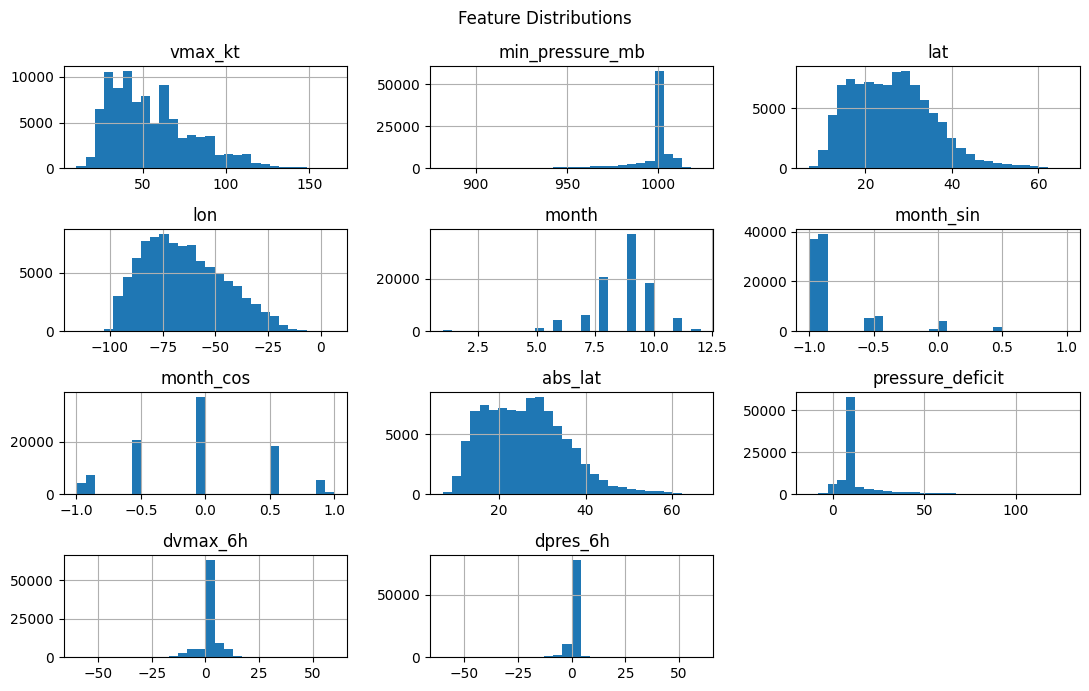

In [7]:
axes = train_df[FEATURE_NAMES].hist(figsize=(11, 7), bins=28)
plt.suptitle('Feature Distributions')
plt.tight_layout()

x_train, y_train, x_val, y_val = split_dataset(train_df, seed=42)
model, feature_mean, feature_std, val_accuracy, val_balanced_accuracy, val_auc = train_model(
    x_train=x_train,
    y_train=y_train,
    x_val=x_val,
    y_val=y_val,
    epochs=140,
    batch_size=512,
    learning_rate=9e-4,
    weight_decay=1e-4,
    seed=42,
)
print(f'Validation accuracy: {val_accuracy:.4f}')
print(f'Validation balanced accuracy: {val_balanced_accuracy:.4f}')
print(f'Validation AUROC: {val_auc:.4f}')

In [9]:
model_path = "../models/huricaines.pt"
save_model_bundle(
    path=model_path,
    model=model,
    feature_mean=feature_mean,
    feature_std=feature_std,
    model_version='0.8.1',
    val_accuracy=val_accuracy,
    val_balanced_accuracy=val_balanced_accuracy,
    val_auc=val_auc,
    dataset_rows=int(len(train_df)),
)
print(f'Saved model artifact to: {model_path}')

Saved model artifact to: ../models/huricaines.pt
